<a href="https://colab.research.google.com/github/RiyaDhami13/Student-Performance-Analyzer/blob/main/Student_Performance_Analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dskagglemt/student-performance-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-data-set' dataset.
Path to dataset files: /kaggle/input/student-performance-data-set


In [22]:
#The setup
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [23]:
#Theme setting
sns.set_theme(style="whitegrid",palette="deep")
plt.rcParams["figure.figsize"] = (8,5) #defines the default size for plt methods


In [24]:
import pandas as pd

path = "/root/.cache/kagglehub/datasets/dskagglemt/student-performance-data-set/versions/1/student-mat.csv"

df = pd.read_csv(path, sep=";")
print(df.shape)
print(df.head())

(395, 33)
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [25]:
#Basic info
print(df.info())
print(df.describe().T)
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
# Dataset: 395 students, 33 features
# Average final grade: 10.4/20 — majority barely passing
# Max absences: 75 — extreme outlier exists
# No missing values — dataset is clean

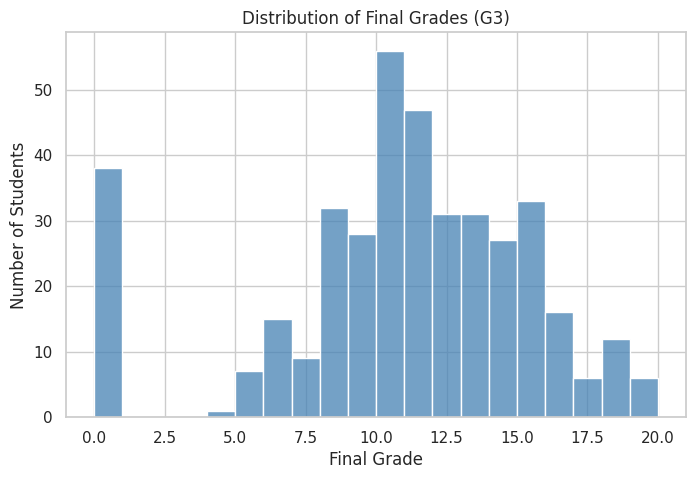

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df["G3"], bins=20, color="steelblue")
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

In [8]:
# G3 distribution shows:
# - Most students cluster around 10-12 (barely passing)
# - ~40 students scored 0 — likely dropouts or final exam absences
# - Very few students score above 18 — high achievers are rare

In [27]:
print(df[df["G3"] == 0].shape[0])
print(df[df["G3"] > 0].shape[0])

38
357


In [28]:
df_clean = df[df["G3"] > 0].copy()
print(df_clean.shape)

(357, 33)


In [11]:
# Removed 38 students with G3 = 0 (likely dropouts/absent for final)
# Working dataset: 357 students
# Original dataset preserved in df

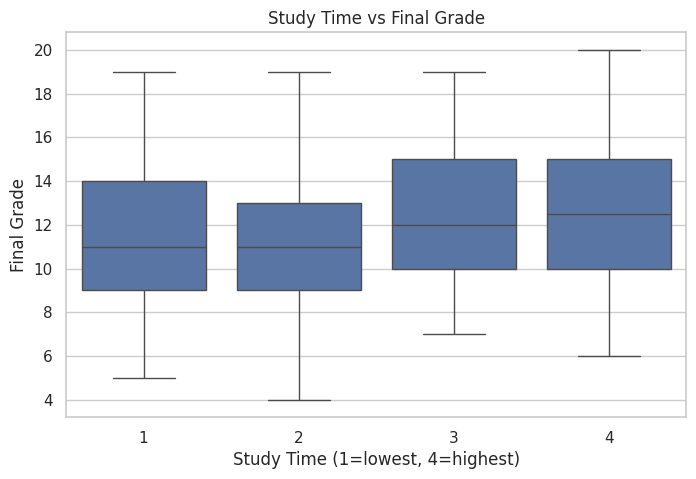

In [29]:
sns.boxplot(x="studytime", y="G3", data=df_clean)
plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time (1=lowest, 4=highest)")
plt.ylabel("Final Grade")
plt.show()

In [13]:
# Study time vs G3:
# Weak positive relationship — more study = slightly higher median
# But huge overlap between groups
# Study time alone does not determine final grade
# Other factors must be involved

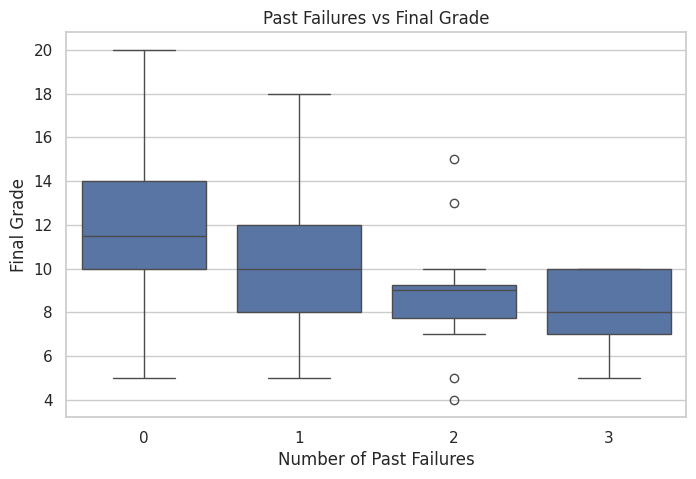

In [30]:
sns.boxplot(x="failures", y="G3", data=df_clean)
plt.title("Past Failures vs Final Grade")
plt.xlabel("Number of Past Failures")
plt.ylabel("Final Grade")
plt.show()

In [15]:
# Past failures vs G3:
# Strongest relationship seen so far — clear downward trend
# 0 failures → median ~12, 3 failures → median ~8
# Much cleaner than study time
# Outliers exist at 2 failures — rare students who recovered
# Past failure is a strong negative predictor of final grade

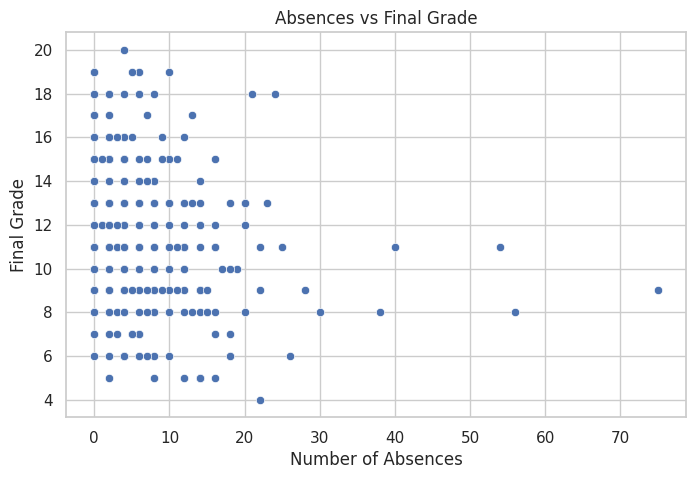

In [31]:
sns.scatterplot(x="absences", y="G3", data=df_clean)
plt.title("Absences vs Final Grade")
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.show()


In [17]:
# Absences vs G3:
# Weak relationship — no clear pattern
# Most students have 0-20 absences
# High absences don't guarantee low grades
# Weaker predictor than past failures
# Outlier: 1 student with 75 absences still scored 9

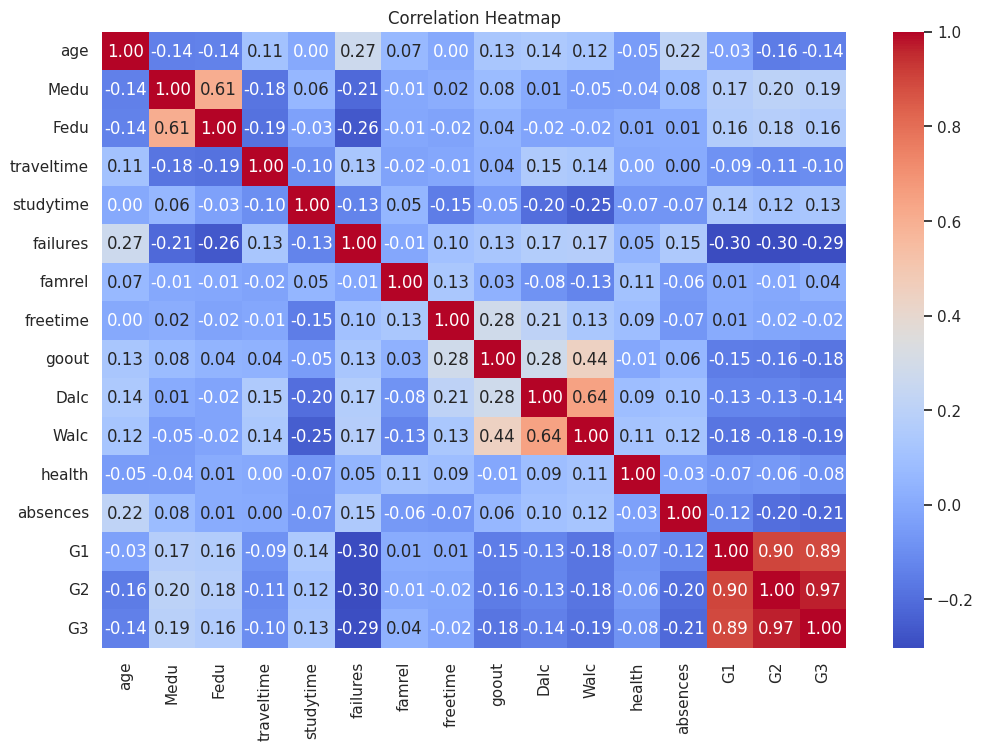

In [32]:
plt.figure(figsize=(12,8))
numeric_df = df_clean.select_dtypes(include="number")
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [19]:
# Correlation with G3:
# Strongest predictors:
# failures: -0.29 (most damaging factor)
# Medu: 0.19 (mother's education helps)
# Fedu: 0.16 (father's education helps)
# studytime: 0.13 (weak positive)
# G1/G2 → G3: 0.89-0.97 (early grades predict final grade strongly)
# Key insight: family background and past performance matter more than study time

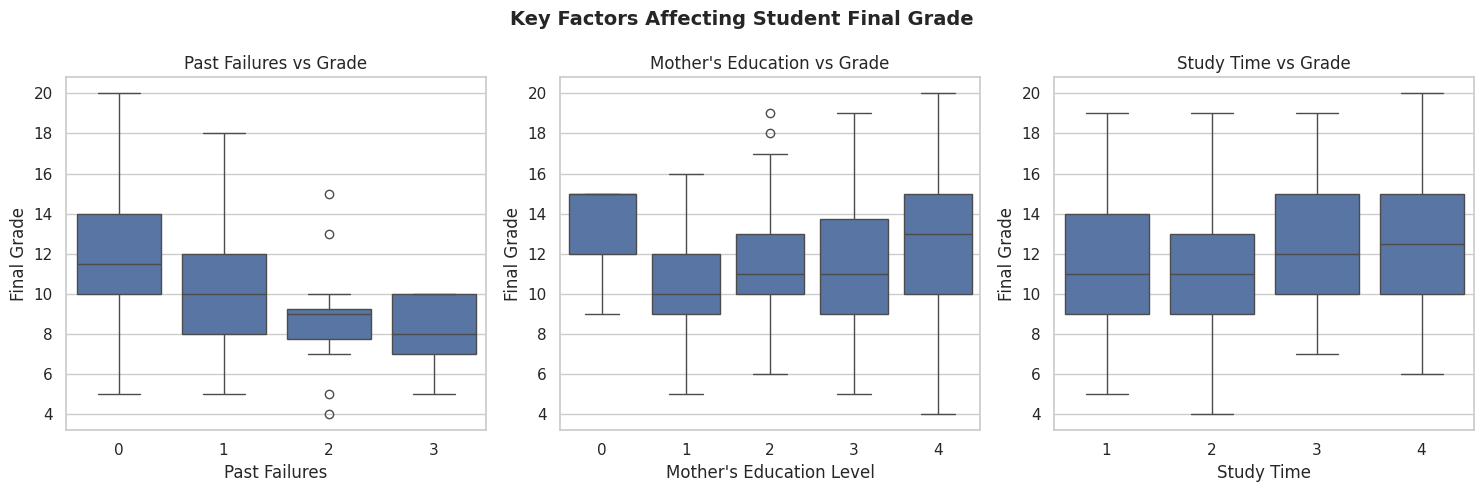

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Failures
sns.boxplot(x="failures", y="G3", data=df_clean, ax=axes[0])
axes[0].set_title("Past Failures vs Grade")
axes[0].set_xlabel("Past Failures")
axes[0].set_ylabel("Final Grade")

# Mother's Education
sns.boxplot(x="Medu", y="G3", data=df_clean, ax=axes[1])
axes[1].set_title("Mother's Education vs Grade")
axes[1].set_xlabel("Mother's Education Level")
axes[1].set_ylabel("Final Grade")

# Study Time
sns.boxplot(x="studytime", y="G3", data=df_clean, ax=axes[2])
axes[2].set_title("Study Time vs Grade")
axes[2].set_xlabel("Study Time")
axes[2].set_ylabel("Final Grade")

plt.suptitle("Key Factors Affecting Student Final Grade",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# PROJECT CONCLUSION — Student Performance Analyzer
# ============================================

# QUESTION: What factors most affect a student's final grade?

# FINDING 1 — Past failures is the most damaging factor
# Students with 0 failures: median grade ~12
# Students with 3 failures: median grade ~8
# Clear, consistent, unavoidable pattern

# FINDING 2 — Family education matters more than study time
# Mother's education correlates 0.19 with G3
# Study time correlates only 0.13 with G3
# Home environment shapes performance more than effort alone

# FINDING 3 — Early grades predict final grade almost perfectly
# G1 and G2 correlate 0.89-0.97 with G3
# A student struggling in period 1 will almost certainly
# struggle in period 3 without intervention

# FINDING 4 — 9.6% of students never reached the final exam
# 38 out of 395 scored 0 — removed as likely dropouts
# Dropout risk is a separate problem worth analyzing

# RECOMMENDATION:
# Schools should focus intervention on:
# 1. Students who have failed before
# 2. Students performing poorly in period 1
# These two groups are most at risk of final failure